In [1]:
import torch
from torch import nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
device = "cpu"

In [3]:
max_tokens = 128

In [4]:
from torch.utils.data import Dataset,DataLoader,random_split

class CodeDataset(Dataset):
    def __init__(self,data,max_tokens):
        self.x = data["buggy"]
        self.x = list(map(self.tokensize,self.x))
        temp = np.zeros((len(self.x),max_tokens))
        for i in range(len(temp)):
            temp[i,:min(len(self.x[i]),max_tokens)] = np.array(self.x[i])
        self.x = torch.LongTensor(temp)
        self.y = data["fixed"]
        self.y = list(map(self.tokensize,self.y))
        temp = np.zeros((len(self.y),max_tokens))
        for i in range(len(temp)):
            temp[i,:min(len(self.y[i]),max_tokens)] = np.array(self.y[i])
        self.y = torch.LongTensor(temp)

    def __len__(self):
        return len(self.x)

    keywords = ['abstract', 'continue', 'for', 'new', 'switch', 'assert', 'default', 'goto', 'package', 'synchronized', 'boolean', 'do', 'if',
                'private', 'this', 'break', 'double', 'implements', 'protected', 'throw', 'byte', 'else', 'import', 'public', 'throws', 'case',
                'enum', 'instanceof', 'return', 'transient', 'catch', 'extends', 'int', 'short', 'try', 'char', 'final', 'interface', 'static',
                'void', 'class', 'finally', 'long', 'strictfp', 'volatile', 'const', 'float', 'native', 'super', 'while','instanceof','java',
                'lang','String','STRING','METHOD','VAR','TYPE','true','false','[END]','[START]']

    operator = []

    def tokensize(self,x):
        def val(x):
            if x == '\n':
                return 126-32+2
            return ord(x)-32+1
        j = -1
        tokens = [126-32+3+self.keywords.index('[START]')]
        for i in range(len(x)):
            if x[i].isalpha():
                if j == -1:
                    j = i
            else:
                if j != -1:
                    if x[j:i] in self.keywords:
                        tokens.append(126-32+3+self.keywords.index(x[j:i]))
                    else:
                        tokens.extend(list(map(val,x[j:i])))
                    j = -1
                tokens.append(val(x[i]))
        tokens.append(126-32+3+self.keywords.index('[END]'))
        return tokens
    @staticmethod
    def getVocab():
        return 126-32+3+len(CodeDataset.keywords)
    @staticmethod
    def detokensize(x):
        def val(x):
            if x == 126-32+2:
                return '\n'
            if x <126-32+2:
                return chr(x+32-1)
            return CodeDataset.keywords[x -126+32-3]
        return "".join(list(map(val,x)))
    def __getitem__(self,idx):
        return self.x[idx],self.y[idx]

In [5]:
class Embedder(nn.Module):
    def __init__(self,vocab,embemding_dim):
        super().__init__()
        self.emb = nn.Embedding(vocab,embemding_dim)
    def forward(self,x):
        return self.emb(x)

# class Attention(nn.Module):
#     def __init__(self,size,size2):
#         super().__init__()
#         self.W_Q = nn.Parameter(torch.randn((size,size2)))
#         self.W_K = nn.Parameter(torch.randn((size,size2)))
#         self.W_V = nn.Parameter(torch.randn((size,size2)))
#         self.sf = nn.Softmax(dim=-1)
#         self.size2 = size2

#     def forward(self,x):
#         return self.sf(1/np.sqrt(self.size2)*((x@self.W_Q)@(x@self.W_V).mT))@x@self.W_V

class AddAndNormalise(nn.Module):
    def __init__(self):
        super().__init__()
        self.a = nn.Parameter(torch.ones(1))
        self.b = nn.Parameter(torch.zeros(1))

    def forward(self,x,y):
        h = x+y
        return self.a*(h - h.mean(-1,keepdim=True))/(h.std(-1,keepdim=True)+1e-8)+self.b


class MultiHeadAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers,device):
        super().__init__()
        self.device = device
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads)))

        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x,mask=False):
        batchsize, input_len = x.shape[0],x.shape[1]

        Q = x@self.W_Q
        K = x@self.W_K
        V = x@self.W_V

        # previous attempt
        # Qs = torch.chunk(Q,self.nheads,dim = -1)
        # Ks = torch.chunk(K,self.nheads,dim = -1)
        # Vs = torch.chunk(V,self.nheads,dim = -1)
        # c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        # return c@self.W_O

        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)

        att_sc,out = self.scaledDotProduct(Qs,Ks,Vs,mask)
        out = out.transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O,att_sc

    def scaledDotProduct(self,Q,K,V,mask):
        att_sc = 1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(self.device))*(Q@(K.transpose(-1,-2)))
        if mask:
          # mask need to be inverted
            m = torch.tril(torch.ones(att_sc.shape[-2:])).bool().to(device)
            att_sc = torch.masked_fill(att_sc,~m,float("-inf"))
        att_sc = self.sf(att_sc)
        return att_sc,att_sc@V

class Encoder(torch.nn.Module):
    def __init__(self,input_dim,heads,hidden_dim,device):
        super().__init__()
        self.device = device
        self.input_dim = input_dim
        if input_dim % heads != 0:
            raise ArithmeticError(f"take a divisible number for heads , heads{heads} , input_dim{input_dim}")
        self.att = MultiHeadAttention(heads,input_dim,input_dim//heads,device)
        self.norm = AddAndNormalise()
        self.W_1 = nn.Parameter(torch.randn((input_dim,hidden_dim)))
        self.b_1 = nn.Parameter(torch.randn(hidden_dim))
        self.W_2 = nn.Parameter(torch.randn((hidden_dim,input_dim)))
        self.b_2 = nn.Parameter(torch.randn(input_dim))
        self.r = nn.ReLU()
        self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2
        self.norm2 = AddAndNormalise()

    def forward(self,x):
        x2 = self.position_embedded(x)
        x3 = self.att(x2)[0]
        #print(x3.shape)
        x4 = self.norm(x2,x3)

        x5 = self.ff(x4)
        return self.norm2(x5,x4)

    def position_embedded(self,x):
        # x shape assumed to be: (batch_size, seq_len, d_model)
        seq_len = x.shape[1]
        d_model = x.shape[2]
        # 1. Create positions vector 'i' -> shape: (seq_len, 1)
        # This matches your loop: for i in range(x.shape[1])
        i_indices = torch.arange(0,seq_len, dtype=x.dtype, device=x.device).unsqueeze(1)
        
        # 2. Create dimensions vector 'j' -> shape: (d_model // 2,)
        # We only need the even indices because j // 2 is identical for pairs (0,1), (2,3), etc.
        j_indices = torch.arange(0, d_model, 2, dtype=x.dtype, device=x.device)
        
        # 3. Compute the denominator term: 10000^(2*(j//2) / d_model)
        # Note: Transformer standard usually uses 10000, but keeping your 1000 from the prompt
        div_term = torch.pow(1000.0, (2 * (j_indices // 2) / d_model))
        
        # 4. Compute the inner angles -> shape: (seq_len, d_model // 2)
        angles = i_indices / div_term
        
        # 5. Create the encoding matrix -> shape: (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model, dtype=x.dtype, device=x.device)
        
        # Assign Sin to even indices and Cos to odd indices
        pe[:, 0::2] = torch.sin(angles)
        pe[:, 1::2] = torch.cos(angles)
        # 6. Add to x using broadcasting -> shape: (1, seq_len, d_model)
        x += pe.unsqueeze(0)
        
        return x


class MultiHeadCrossAttention(nn.Module):
    def __init__(self,nheads,input_dim,attention_layers,device):
        super().__init__()
        self.device = device
        self.W_Q = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_K = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_V = nn.Parameter(torch.randn((input_dim,attention_layers*nheads)))
        self.W_O = nn.Parameter(torch.randn((attention_layers*nheads,attention_layers*nheads)))

        self.sf = nn.Softmax(dim=-1)
        self.attention_layers = attention_layers
        self.nheads = nheads

    def forward(self,x,y,mask=True):
        batchsize, input_len, input_len2 = x.shape[0],x.shape[-2],y.shape[-2]
        Q = x@self.W_Q
        K = y@self.W_K
        V = y@self.W_V
        # previous attempt
        # Qs = torch.chunk(Q,self.nheads,dim = -1)
        # Ks = torch.chunk(K,self.nheads,dim = -1)
        # Vs = torch.chunk(V,self.nheads,dim = -1)
        # c = torch.concat([self.scaledDotProduct(Qs[i],Ks[i],Vs[i]) for i in range(self.nheads)],dim=-1)
        # return c@self.W_O

        Qs = Q.reshape(batchsize,input_len,self.nheads,self.attention_layers).transpose(1,2)
        Ks = K.reshape(batchsize,input_len2,self.nheads,self.attention_layers).transpose(1,2)
        Vs = V.reshape(batchsize,input_len2,self.nheads,self.attention_layers).transpose(1,2)

        out = self.scaledDotProduct(Qs,Ks,Vs,mask).transpose(1,2).reshape(batchsize,input_len,-1)
        return out@self.W_O


    def scaledDotProduct(self,Q,K,V,mask):
      att_sc = 1/torch.sqrt(torch.Tensor([Q.shape[-1]]).to(self.device))*(Q@(K.transpose(-1,-2)))
      if mask:
        m = torch.tril(torch.ones(att_sc.shape[-2:])).bool().to(device)
        # mask need to be inverted
        att_sc = torch.masked_fill(att_sc,~m,float("-inf"))
      return self.sf(att_sc)@V

class Decoder(torch.nn.Module):
    def __init__(self,vocab,input_dim,heads,output_size,device):
        """
        masked att
        add norm
        att
        add norm
        feed forward
        add norm

        linear
        softmax
        """
        super().__init__()
        self.device = device
        self.output_size = output_size
        if input_dim % heads != 0:
            raise ArithmeticError(f"take a divisible number for heads , heads{heads} , attention_dim{input_dim}")
        self.att = MultiHeadAttention(heads,input_dim,input_dim//heads,device)
        self.att2 = MultiHeadCrossAttention(heads,input_dim,input_dim//heads,device)
        self.norm = AddAndNormalise()
        self.norm2 = AddAndNormalise()
        # self.W_1 = nn.Parameter(torch.randn((attention_dim+input_dim,hidden_dim)))
        # self.b_1 = nn.Parameter(torch.randn(hidden_dim))
        # self.W_2 = nn.Parameter(torch.randn((hidden_dim,output_dim)))
        # self.b_2 = nn.Parameter(torch.randn(output_dim))
        # self.r = nn.ReLU()
        # self.ff = lambda x : self.r(x@self.W_1+self.b_1)@self.W_2 + self.b_2
        self.ff = nn.Linear(input_dim,vocab)

    def forward(self,x,y,mask=True):
        outputs = []
        k = y.shape
        y = self.position_embedded(y)
        x2 = self.att(y,mask)[0]
        x3 = self.norm(y,x2)
        x4 = self.att2(x3,x,False)
        x5 = self.norm2(x2,x4)#*
        x6 = self.ff(x5)
        x7 = torch.zeros_like(x6)
        x7[:,1:,:] = x6[:,:-1,:]
        x7[:,0,-1] = 1
        return x7

    def predict_next(self,x,y,mask=True):
        y = self.position_embedded(y)
        x2 = self.att(y,mask)[0]
        x3 = self.norm(y,x2)
        x4 = self.att2(x3,x,False)
        x5 = self.norm2(x2,x4)
        x6 = self.ff(x5)
        return x6[:,-1,:]
    def position_embedded(self,x):
        # x shape assumed to be: (batch_size, seq_len, d_model)
        seq_len = x.shape[1]
        d_model = x.shape[2]
        
        # 1. Create positions vector 'i' -> shape: (seq_len, 1)
        # This matches your loop: for i in range(x.shape[1])
        i_indices = torch.arange(seq_len, dtype=x.dtype, device=x.device).unsqueeze(1)
        
        # 2. Create dimensions vector 'j' -> shape: (d_model // 2,)
        # We only need the even indices because j // 2 is identical for pairs (0,1), (2,3), etc.
        j_indices = torch.arange(0, d_model, 2, dtype=x.dtype, device=x.device)
        
        # 3. Compute the denominator term: 10000^(2*(j//2) / d_model)
        # Note: Transformer standard usually uses 10000, but keeping your 1000 from the prompt
        div_term = torch.pow(1000.0, (2 * (j_indices // 2) / d_model))
        
        # 4. Compute the inner angles -> shape: (seq_len, d_model // 2)
        angles = i_indices / div_term
        
        # 5. Create the encoding matrix -> shape: (seq_len, d_model)
        pe = torch.zeros(seq_len, d_model, dtype=x.dtype, device=x.device)
        
        # Assign Sin to even indices and Cos to odd indices
        pe[:, 0::2] = torch.sin(angles)
        pe[:, 1::2] = torch.cos(angles)
        
        # 6. Add to x using broadcasting -> shape: (1, seq_len, d_model)
        x += pe.unsqueeze(0)
        
        return x

class EncoderDecoder(nn.Module):
    def __init__(self,vocab,embedding_dim,output_size,device):
        super().__init__()
        self.device = device
        self.emb = Embedder(vocab,embedding_dim)
        self.encoder = Encoder(embedding_dim,8,128,device)
        self.decoder = Decoder(vocab,embedding_dim,8,output_size,device)
        self.output_size = output_size
    def forward(self,x,y):
        x2 = self.emb(x)
        x3 = self.encoder(x2)
        x4 = self.decoder(x3,self.emb(y))
        return x4
    def predict(self,x,y):
        x2 = self.emb(x)
        x3 = self.encoder(x2)
        y0 = torch.zeros([y.shape[0],self.output_size],dtype=torch.long).to(self.device)
        y0[:,0] = y
        y_emb = self.emb(y0[:,:1])
        for i  in range(self.output_size-1):
            y_ = self.decoder.predict_next(x3,y_emb)
            y0[:,i+1] = torch.argmax(y_,dim=-1)
            y_emb = self.emb(y0[:,:i+2])
        return y0

In [6]:
model = EncoderDecoder(CodeDataset.getVocab(),128,max_tokens,device)

In [7]:
model.load_state_dict(torch.load(f"./Transformer2_model_parameter.trhmodel"))

<All keys matched successfully>

In [8]:
model.eval()
sum(p.numel() for p in model.parameters() if p.requires_grad == True)

270503

In [9]:
splits = {'train': 'small/train-00000-of-00001.parquet', 'validation': 'small/validation-00000-of-00001.parquet', 'test': 'small/test-00000-of-00001.parquet'}
test_dataset = pd.read_parquet("hf://datasets/google/code_x_glue_cc_code_refinement/" + splits["test"])
test_dataset = test_dataset[test_dataset["buggy"].str.len() <= max_tokens]
test_dataset = test_dataset[test_dataset["fixed"].str.len() <= max_tokens]
len(test_dataset)
np.asarray(test_dataset.head(20))

array([[4,
        'public void METHOD_1 ( ) { TYPE_1 . METHOD_2 ( METHOD_3 ( ) , METHOD_4 ( ) . getString ( VAR_1 ) , VAR_2 ) . show ( ) ; } \n',
        'private void METHOD_1 ( ) { TYPE_1 . METHOD_2 ( METHOD_3 ( ) , METHOD_4 ( ) . getString ( VAR_1 ) , VAR_2 ) . show ( ) ; } \n'],
       [6,
        'private static boolean METHOD_1 ( final byte status ) { return status == ( VAR_1 ) ; } \n',
        'private static boolean METHOD_1 ( final int status ) { return status == ( VAR_1 ) ; } \n'],
       [7,
        'public void METHOD_1 ( int VAR_1 , TYPE_1 VAR_2 ) { this . VAR_3 . add ( VAR_1 , VAR_2 ) ; VAR_4 . add ( this ) ; } \n',
        'public void METHOD_1 ( int VAR_1 , TYPE_1 VAR_2 ) { this . VAR_3 . add ( VAR_1 , VAR_2 ) ; } \n'],
       [12,
        'public void METHOD_1 ( TYPE_1 VAR_1 ) { this . VAR_1 = VAR_1 ; } \n',
        'public void METHOD_1 ( TYPE_1 VAR_1 ) { } \n'],
       [13,
        'public java.lang.Boolean METHOD_1 ( java.lang.String id ) { return VAR_1 . METHOD_1 

In [10]:
test_dataset = CodeDataset(test_dataset,max_tokens)
test_data = DataLoader(test_dataset,256)

In [46]:
model.to(device)
model.eval()
total = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        x = x.to(device)
        y = y.to(device)
        pred = model(x,y)
        pred = torch.argmax(pred,dim=-1)
        total += ((pred == y)*(y != 0)).sum()      
        n += len(y.reshape(-1)) - (y==0).sum()
    j = (y[0] == 0).nonzero(as_tuple=True)[0][0]
    print("x:",CodeDataset.detokensize(x[0]))
    print("pred:",CodeDataset.detokensize(pred[0,:j]))
    print("y:",CodeDataset.detokensize(y[0,:j]))
    print("acc:",total/n)

x: [START]public void METHOD_1 ( final int position , final int VAR_1 ) { VAR_2 [ VAR_1 ] = position > 0 ; } 
[END]
pred: [START]public void METHOD_1 ( final p position , final final VAR_1 ) { VAR VAR VARosition ) 0 ) ;t  ) )_2 ) ; } 
etova 
 ;_1 ; ; 
 
[END]
y: [START]public void METHOD_1 ( final int position , final int VAR_1 ) { if ( position > 0 ) add ( VAR_1 ) ; else remove ( VAR_1 ) ; } 
[END]
acc: tensor(0.8629)


In [44]:
model.to(device)
model.eval()
total = 0
n = 0
with torch.no_grad():
    for (x,y) in test_data:
        x = x.to(device)
        y = y.to(device)
        pred = model.predict(x,y[:,0])
        total += ((pred == y)*(y != 0)).sum()      
        n += len(y.reshape(-1)) - (y==0).sum()
        x = x.to("cpu")
        y = y.to("cpu")
    print("acc:",total/n)

acc: tensor(0.4955)


## weight analysis

In [13]:
x2 = model.emb(x)
x3 = model.encoder(x2)
x2 = model.encoder.position_embedded(x2)
att_encoder,att_sc1 = model.encoder.att(x2)
print(att_sc1.shape)
x4 = model.decoder(x3,model.emb(y))
x2 = model.decoder.position_embedded(model.emb(y))
att_encoder,att_sc2 = model.decoder.att(x2,True)
print(att_sc2.shape)
print(x4.shape)

torch.Size([134, 8, 128, 128])
torch.Size([134, 8, 128, 128])
torch.Size([134, 128, 159])


In [14]:
import gc
def clear_cache():
    gc.collect()
    torch.cuda.empty_cache()

In [15]:
clear_cache()

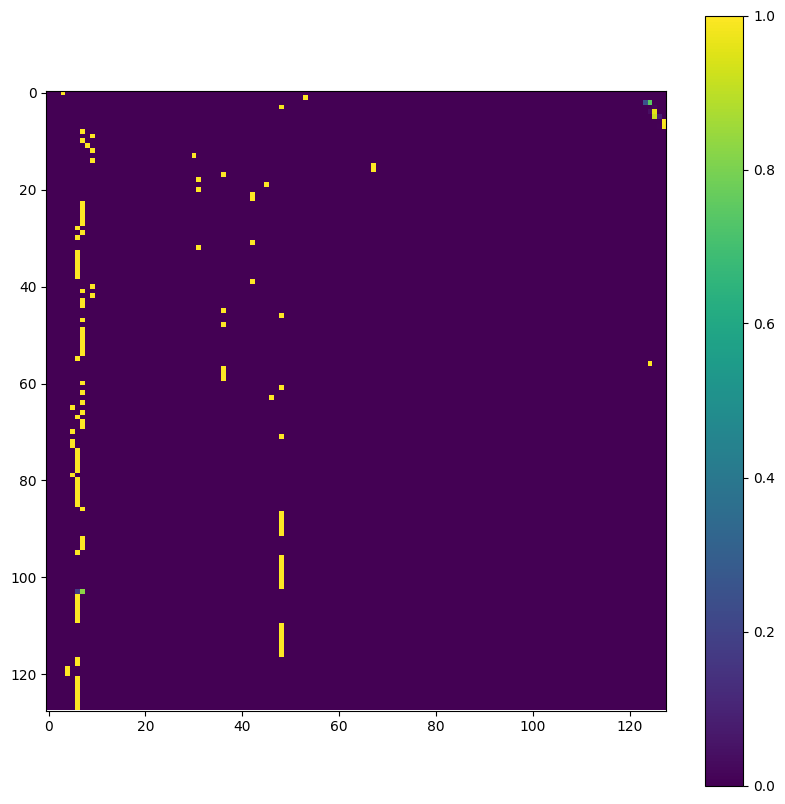

In [16]:
plt.figure(figsize=(10, 10))
plt.imshow(att_sc1[0,0,:,:].cpu().detach().numpy())
plt.colorbar()

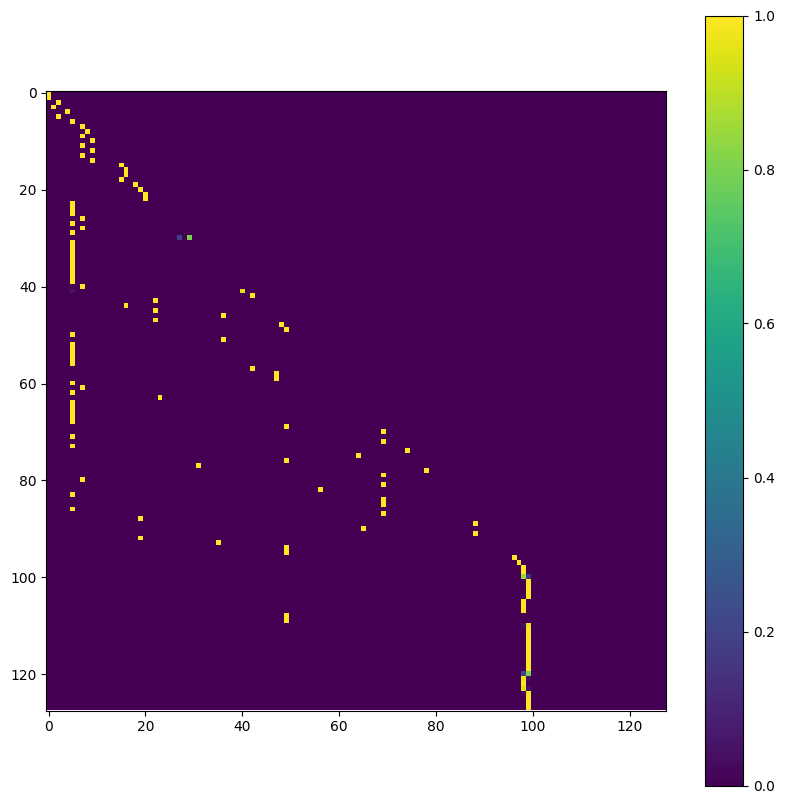

In [17]:
plt.figure(figsize=(10, 10))
plt.imshow(att_sc2[0,0,:,:].cpu().detach().numpy())
plt.colorbar()

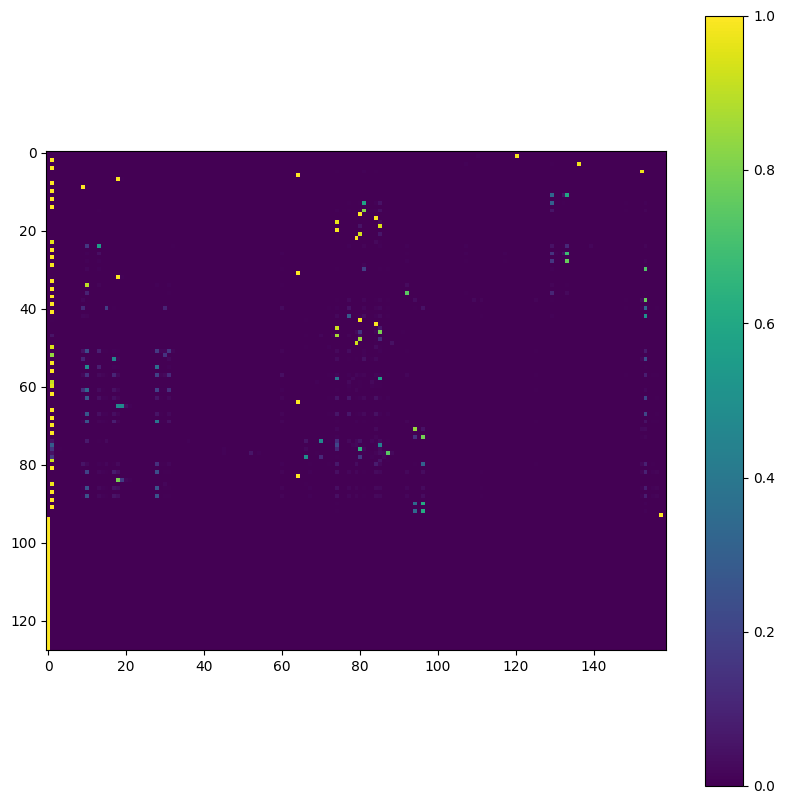

In [21]:
x5 = model(x,y)
x5 =torch.softmax(x5,dim=-1)
plt.figure(figsize=(10, 10))
plt.imshow(x5[0].cpu().detach().numpy())
plt.colorbar()

In [36]:
x2 = model.emb(x)
x3 = model.encoder(x2)


{intfinalVAR


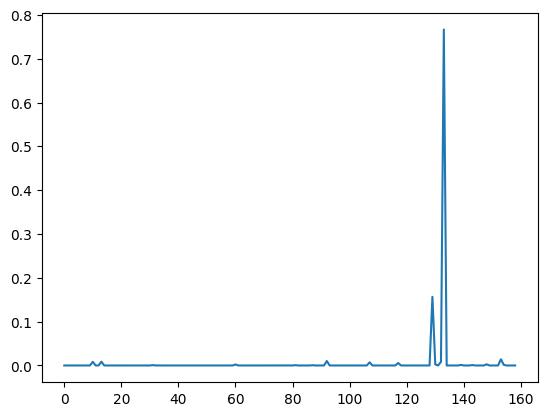

In [70]:
x4 = model.decoder.predict_next(x3,model.emb(y[:,:28]))
plt.plot(torch.softmax(x4[0],dim=-1).detach().numpy())
print(CodeDataset.detokensize((torch.softmax(x4[0],dim=-1)>1e-2).nonzero()))